# Bank Personal Loan | Exploratory Data Analysis & Prediction

## Project Overview

This notebook explores a bank's customer data and builds classification models to predict which customers are likely to accept a personal loan offer. It covers data cleaning, exploratory analysis, preprocessing, and a comparison of three models: Logistic Regression, Naive Bayes and K-Nearest Neighbors.

## Project Objective

**Business goal:** help the bank target its next personal loan campaign by identifying customers who are most likely to accept an offer.

Only about 9.6% of customers accepted the offer in the previous campaign, so the classes are highly imbalanced and accuracy alone is misleading. The models are therefore compared with precision, recall, F1, ROC-AUC, PR-AUC and log loss.

## Dataset Overview

The dataset contains information on 5,000 bank customers (a publicly available marketing-campaign dataset), and the goal is to predict whether a customer will accept a personal loan offer or not.

### Feature Description

| Feature | Description |
|---|---|
| Age | Customer's age |
| Experience | Years of professional experience |
| Income | Annual income ($000) |
| ZIP Code | Customer’s residential area |
| Family | Number of family members |
| CCAvg | Average monthly credit card spending ($000); converted to annual spending during cleaning |
| Education | Education level (1: Undergrad, 2: Graduate, 3: Advanced/Professional) |
| Mortgage | Value of house mortgage if any ($000) |
| Personal Loan | Target variable (1 = accepted, 0 = rejected) |
| Securities Account | Has a securities account? (1/0) |
| CD Account | Has a certificate of deposit account? (1/0) |
| Online | Uses online banking? (1/0) |
| CreditCard | Has a credit card issued by the bank? (1/0) |

## Tools & Libraries

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Plotly
- Scikit-learn

## Import Libraries & Data

In [1]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Model selection & evaluation
from sklearn.model_selection import (train_test_split, StratifiedKFold, GridSearchCV,
                                     cross_validate, cross_val_predict)
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score, log_loss,
                             classification_report, ConfusionMatrixDisplay,
                             RocCurveDisplay, PrecisionRecallDisplay)

# Preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

In [2]:
# Import data

Data = pd.read_csv("../data/Bank_Personal_Loan_Modelling.csv")

# Work on a copy so the raw data stays untouched
df = Data.copy()

### Dataset Information

In [3]:
Data.head(5)

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1/60,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1/50,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1/00,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2/70,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1/00,2,0,0,0,0,0,1


### Initial Dataset Inspection

The dataset was first inspected to understand its dimensions, structure, data types, and basic descriptive statistics.

In [4]:
Data.describe()

,ID,Age,Experience,Income,ZIP Code,Family,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000
mean,2500.500000,45.338400,20.104600,73.774200,93152.503000,2.396400,1.881000,56.498800,0.096000,0.104400,0.06040,0.596800,0.294000
std,1443.520003,11.463166,11.467954,46.033729,2121.852197,1.147663,0.839869,101.713802,0.294621,0.305809,0.23825,0.490589,0.455637
min,1.000000,23.000000,-3.000000,8.000000,9307.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,1250.750000,35.000000,10.000000,39.000000,91911.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
50%,2500.500000,45.000000,20.000000,64.000000,93437.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.00000,1.000000,0.000000
75%,3750.250000,55.000000,30.000000,98.000000,94608.000000,3.000000,3.000000,101.000000,0.000000,0.000000,0.00000,1.000000,1.000000
max,5000.000000,67.000000,43.000000,224.000000,96651.000000,4.000000,3.000000,635.000000,1.000000,1.000000,1.00000,1.000000,1.000000


In [5]:
#Number_of_rows_columns

rows, columns = df.shape

print(f"The Number of rows in this Dataset is: {rows}")
print(f"The Number of columns in this Dataset is: {columns}")

The Number of rows in this Dataset is: 5000
The Number of columns in this Dataset is: 14


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   ID                  5000 non-null   int64 
 1   Age                 5000 non-null   int64 
 2   Experience          5000 non-null   int64 
 3   Income              5000 non-null   int64 
 4   ZIP Code            5000 non-null   int64 
 5   Family              5000 non-null   int64 
 6   CCAvg               5000 non-null   object
 7   Education           5000 non-null   int64 
 8   Mortgage            5000 non-null   int64 
 9   Personal Loan       5000 non-null   int64 
 10  Securities Account  5000 non-null   int64 
 11  CD Account          5000 non-null   int64 
 12  Online              5000 non-null   int64 
 13  CreditCard          5000 non-null   int64 
dtypes: int64(13), object(1)
memory usage: 547.0+ KB


Except CCAvg column, all columns are integer.

In [7]:
#Column_Detail

def col_detail (df1):
    col_name = []
    dtypes = []
    count = []
    unique = []
    for col in df1.columns:
        col_name.append(col)
        dtypes.append(df1[col].dtype)
        count.append(len(df1[col]))
        unique.append(len(df1[col].unique()))
        
    output = pd.DataFrame({
        'Column_name' : col_name,
        'Dtype' : dtypes,
        'Count' : count,
        'Unique': unique
    })
    return output

col_detail(df)

,Column_name,Dtype,Count,Unique
0,ID,int64,5000,5000
1,Age,int64,5000,45
2,Experience,int64,5000,47
3,Income,int64,5000,162
4,ZIP Code,int64,5000,467
5,Family,int64,5000,4
6,CCAvg,object,5000,108
7,Education,int64,5000,3
8,Mortgage,int64,5000,347
9,Personal Loan,int64,5000,2


## Data Cleaning

### Missing Values

In [8]:
Num_missing = df.isna().sum().sum()

if Num_missing == 0:
    print("There are no missing values in this dataset.")
else:
    print(f"There are {Num_missing} missing values in this dataset.")

There are no missing values in this dataset.


In this dataset we don’t have missing values, but we should also check for hidden characters and values used as placeholders for missing data such as `-` or `?`. The unique-values check in the "Mistaken Values" section below covers this: the only problems found are the negative Experience values, the "/" used as a decimal separator in CCAvg, and one invalid ZIP code.

### Duplicate Records

In [9]:
#Number_of_Duplicated_records

Num_dup = df.duplicated().sum()

if Num_dup == 0:
    print("There is no duplicated records in this dataset.")
else:
    print(f"There is {Num_dup} duplicated records in this dataset.")

There is no duplicated records in this dataset.


### Columns Names

In [10]:
df.rename(columns={
    "ZIP Code": "ZIP_Code",
    "Personal Loan": "Personal_Loan",
    "Securities Account": "Securities_Account",
    "CD Account": "CD_Account",
    "CreditCard" : "Credit_Card"
    
}, inplace=True)

In [11]:
#Validate
df.columns

Index(['ID', 'Age', 'Experience', 'Income', 'ZIP_Code', 'Family', 'CCAvg',
       'Education', 'Mortgage', 'Personal_Loan', 'Securities_Account',
       'CD_Account', 'Online', 'Credit_Card'],
      dtype='object')

### Mistaken Values

In [12]:
#Unique_Values

for column in df.columns:
    print(f"Unique Values in '{column}':")
    print(df[column].unique())
    print("_"*40)

Unique Values in 'ID':
[   1    2    3 ... 4998 4999 5000]
________________________________________
Unique Values in 'Age':
[25 45 39 35 37 53 50 34 65 29 48 59 67 60 38 42 46 55 56 57 44 36 43 40
 30 31 51 32 61 41 28 49 47 62 58 54 33 27 66 24 52 26 64 63 23]
________________________________________
Unique Values in 'Experience':
[ 1 19 15  9  8 13 27 24 10 39  5 23 32 41 30 14 18 21 28 31 11 16 20 35
  6 25  7 12 26 37 17  2 36 29  3 22 -1 34  0 38 40 33  4 -2 42 -3 43]
________________________________________
Unique Values in 'Income':
[ 49  34  11 100  45  29  72  22  81 180 105 114  40 112 130 193  21  25
  63  62  43 152  83 158  48 119  35  41  18  50 121  71 141  80  84  60
 132 104  52 194   8 131 190  44 139  93 188  39 125  32  20 115  69  85
 135  12 133  19  82 109  42  78  51 113 118  64 161  94  15  74  30  38
   9  92  61  73  70 149  98 128  31  58  54 124 163  24  79 134  23  13
 138 171 168  65  10 148 159 169 144 165  59  68  91 172  55 155  53  89
  28  75 170 120

In [13]:
# Experience Column

df["Experience"]= df["Experience"].abs()


In [14]:
#Validate

df["Experience"].min()

0

Since the Experience column contained some negative values (-1, -2, -3), which are not possible for years of experience, I assumed they were sign typos and applied the absolute value. Setting them to 0 would be another reasonable choice.

As a sanity check, `Age - Experience` (the age at which the customer started working) should not be unrealistically low; the next cell prints its minimum.

In [15]:
# Sanity check: age at which the customer started working
print("Minimum of Age - Experience:", (df['Age'] - df['Experience']).min())

Minimum of Age - Experience: 20


In [16]:
# CCAvg column: replace the "/" decimal separator

df["CCAvg"] = df["CCAvg"].str.replace("/", ".")

The values in the CCAvg column represent decimal numbers. Since some of them contained "/" instead of a decimal point, I replaced "/" with "." to make them understandable by Python.

In [17]:
#Validate

df["CCAvg"].value_counts()

CCAvg
0.30    241
1.00    231
0.20    204
2.00    188
0.80    187
       ... 
3.25      1
3.67      1
4.67      1
8.90      1
2.75      1
Name: count, Length: 108, dtype: int64

In [18]:
# ZIP_Code

minzip = df["ZIP_Code"].min()
maxzip = df["ZIP_Code"].max()

print(f"The minimum number of ZIP_Code is:{minzip}")
print(f"The maximum number of ZIP_Code is:{maxzip}")

The minimum number of ZIP_Code is:9307
The maximum number of ZIP_Code is:96651


In [19]:
df["ZIP_Code"].value_counts()

ZIP_Code
94720    169
94305    127
95616    116
90095     71
93106     57
        ... 
96145      1
94087      1
91024      1
9307       1
94598      1
Name: count, Length: 467, dtype: int64

The minimum value is 9307. All ZIP codes in California have five digits, so this record is invalid and I will remove it.

In [20]:
#Drop_mistaken_value

df.drop(df[df["ZIP_Code"] == 9307].index, inplace=True)

In [21]:
# Validate

minzip = df["ZIP_Code"].min()
maxzip = df["ZIP_Code"].max()

print(f"The minimum number of ZIP_Code is:{minzip}")
print(f"The maximum number of ZIP_Code is:{maxzip}")

The minimum number of ZIP_Code is:90005
The maximum number of ZIP_Code is:96651


Since the values range from 90005 to 96651, all the ZIP codes belong to California.

A five-digit ZIP code has hundreds of unique values, which is too many to use directly as a feature, so I will group customers by the first three digits of the ZIP code (a coarser area) instead.

### CCAvg Column | Type and Units

In [22]:
df["CCAvg"] = df["CCAvg"].astype(float)

In [23]:
df['CCAvg'] = df['CCAvg']*12

In the dataset, CCAvg represents average **monthly** credit card spending, while Income represents **annual** income (both in $000).

To make the units of the two features comparable, I convert monthly spending to annual spending (× 12). From this point on, CCAvg is an annual amount.

### ZIP Code Features

I first tried to map ZIP codes to county and city with the `uszipcode` library. That produced 38 counties and 244 cities (too many categories for the models) and 33 ZIP codes could not be resolved, so I dropped this approach and used the first three digits of the ZIP code instead. The library is not needed to run this notebook.

### first 3 digits of ZIP_Code

In [24]:
# First 3 digits of the ZIP code (a coarser geographic area)
df['ZIP3'] = df['ZIP_Code'].astype(str).str[:3]

# Group rare areas (fewer than 50 customers) into a single 'Other' category
zip_counts = df['ZIP3'].value_counts()
rare_zips = zip_counts[zip_counts < 50].index
df['ZIP3_other'] = df['ZIP3'].where(~df['ZIP3'].isin(rare_zips), 'Other')
df['ZIP3_other'].value_counts()

ZIP3_other
Other    714
900      375
921      279
950      267
945      264
943      257
941      257
947      251
920      248
940      242
913      222
926      182
956      162
902      161
917      150
958      141
931      134
939      102
951       96
946       89
928       81
949       75
911       71
927       62
923       60
930       57
Name: count, dtype: int64

In [25]:
# Approximate area names for frequent ZIP3 prefixes (used for visualization only; areas not listed fall under 'Other')
zip_to_city = {
    '900': 'Los Angeles',
    '901': 'Los Angeles area',
    '902': 'Beverly Hills',
    '913': 'San Fernando Valley',
    '914': 'Sherman Oaks',
    '915': 'Burbank',
    '916': 'North Hollywood',
    '920': 'San Diego area',
    '921': 'San Diego',
    '922': 'Palm Springs',
    '923': 'Inland Empire',
    '924': 'San Bernardino',
    '925': 'Riverside',
    '926': 'Orange County',
    '927': 'Orange County',
    '928': 'Orange County',
    '930': 'Ventura County',
    '931': 'Santa Barbara',
    '939': 'Monterey / Salinas',
    '940': 'San Mateo / Daly City',
    '941': 'San Francisco',
    '943': 'Palo Alto / Stanford',
    '945': 'East Bay / Oakland',
    '946': 'Oakland',
    '947': 'Berkeley',
    '950': 'Santa Clara / Silicon Valley',
    '951': 'San Jose',
    '956': 'Sacramento area',
    '958': 'Sacramento',
}

In [26]:
df['Region'] = df['ZIP3_other'].apply(lambda x: zip_to_city.get(x, 'Other'))

df.head(5)

,ID,Age,Experience,Income,ZIP_Code,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,Credit_Card,ZIP3,ZIP3_other,Region
0,1,25,1,49,91107,4,19.2,1,0,0,1,0,0,0,911,911,Other
1,2,45,19,34,90089,3,18.0,1,0,0,1,0,0,0,900,900,Los Angeles
2,3,39,15,11,94720,1,12.0,1,0,0,0,0,0,0,947,947,Berkeley
3,4,35,9,100,94112,1,32.4,2,0,0,0,0,0,0,941,941,San Francisco
4,5,35,8,45,91330,4,12.0,2,0,0,0,0,0,1,913,913,San Fernando Valley


In [27]:

#drop_ZIP_Code_Column
df = df.drop(columns=['ZIP_Code'])

#drop_ZIP3_Column

df = df.drop(columns=['ZIP3'])

### Unnecessary column

In [28]:
#Remove_unnecessary_column

df = df.drop(columns=['ID'])


In [29]:
df.head()

,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,Credit_Card,ZIP3_other,Region
0,25,1,49,4,19.2,1,0,0,1,0,0,0,911,Other
1,45,19,34,3,18.0,1,0,0,1,0,0,0,900,Los Angeles
2,39,15,11,1,12.0,1,0,0,0,0,0,0,947,Berkeley
3,35,9,100,1,32.4,2,0,0,0,0,0,0,941,San Francisco
4,35,8,45,4,12.0,2,0,0,0,0,0,1,913,San Fernando Valley


## Data Visualization

### Histogram for continuous columns

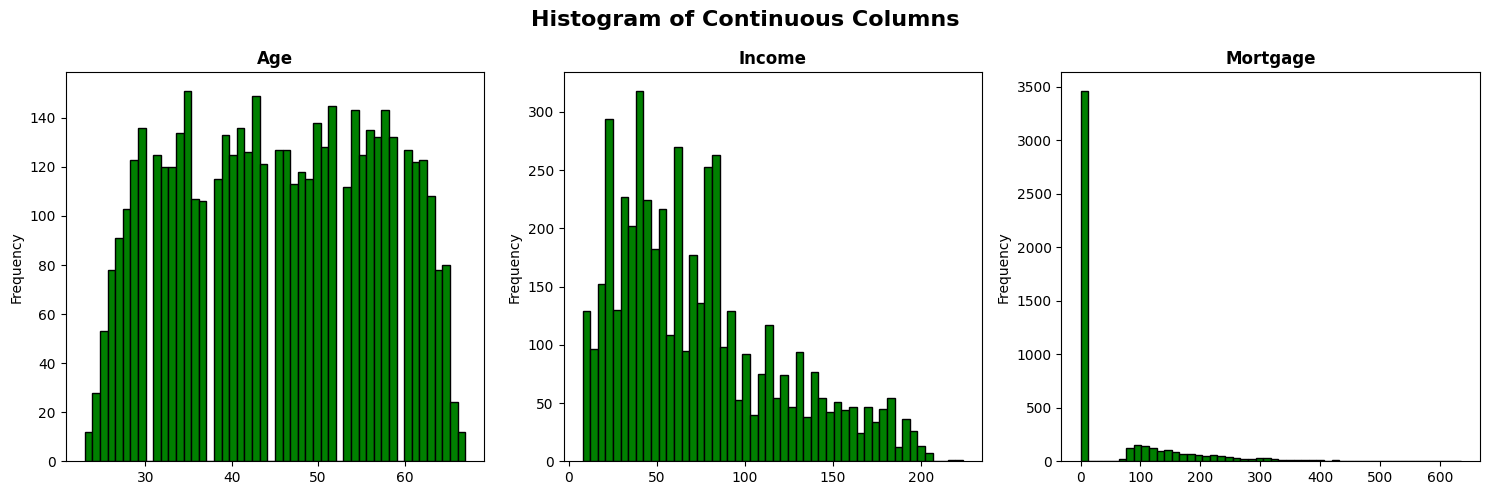

In [30]:
#Continuous_columns

cols = ['Age', 'Income', 'Mortgage']

#3_subplots_in_1_row

fig, axes = plt.subplots(1, 3, figsize=(15, 5))  

for ax, col in zip(axes, cols):
    df[col].plot(kind='hist', bins=50, color='green', edgecolor='black', ax=ax)
    ax.set_title(col, fontsize=12, fontweight='bold')

plt.suptitle("Histogram of Continuous Columns", fontsize=16, fontweight='bold')
plt.tight_layout()

plt.show()

### Distribution of Age

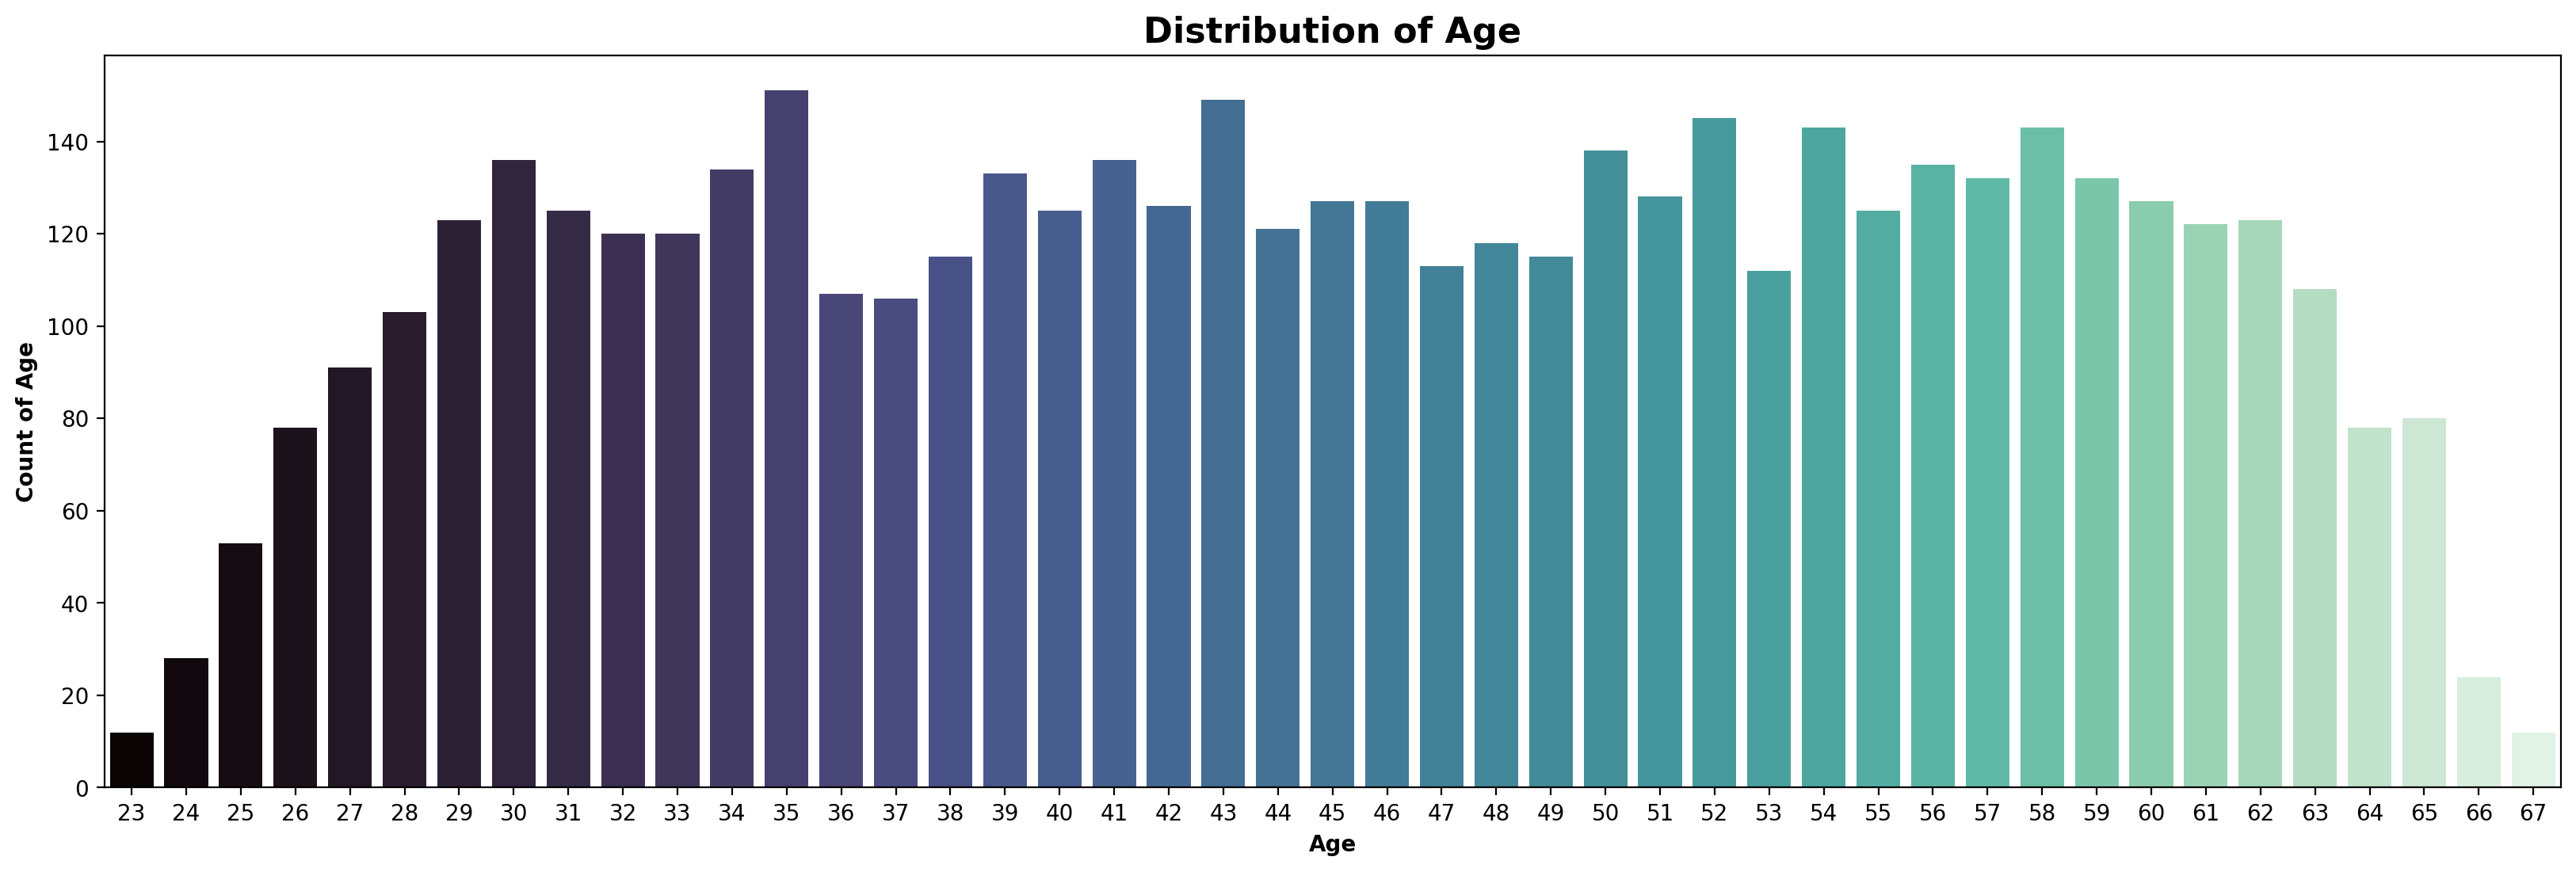

In [31]:
#Distribution_of_Age

plt.figure(figsize=(20,6), dpi=200)

ax=sns.countplot(data=df, x="Age", order=sorted(df["Age"].unique()), 
            palette="mako", hue="Age", legend=False)

plt.xlabel("Age", weight="bold")
plt.ylabel("Count of Age", weight="bold")
plt.title("Distribution of Age",weight="bold", fontsize=16)

plt.show()

As we can see in the plots above, Age is spread fairly evenly between 23 and 67 years, with no strong peak, so it is closer to a uniform distribution than to a bell curve.

### Count of Customers by Region

In [32]:
#Number of Customers by Region

region_counts = df['Region'].value_counts().sort_values(ascending=False)


fig = px.bar(
    region_counts,
    orientation='h',
    labels={'index':'Region','value':'Number of Customers'},
    text_auto=True,              
    title='Number of Customers by Region',
    color=region_counts.index,  
    color_discrete_sequence=px.colors.qualitative.Pastel)

fig.show()

Now I can drop the Region column because I already have the first three digits of the ZIP codes in the ZIP3_other column, which I will use for modeling. The Region column was added solely for better visualization and exploratory analysis.

In [33]:
#drop_Region_Column

df = df.drop(columns=['Region'])

### Personal Loan Distribution

In [34]:
df["Personal_Loan"].value_counts()

Personal_Loan
0    4519
1     480
Name: count, dtype: int64

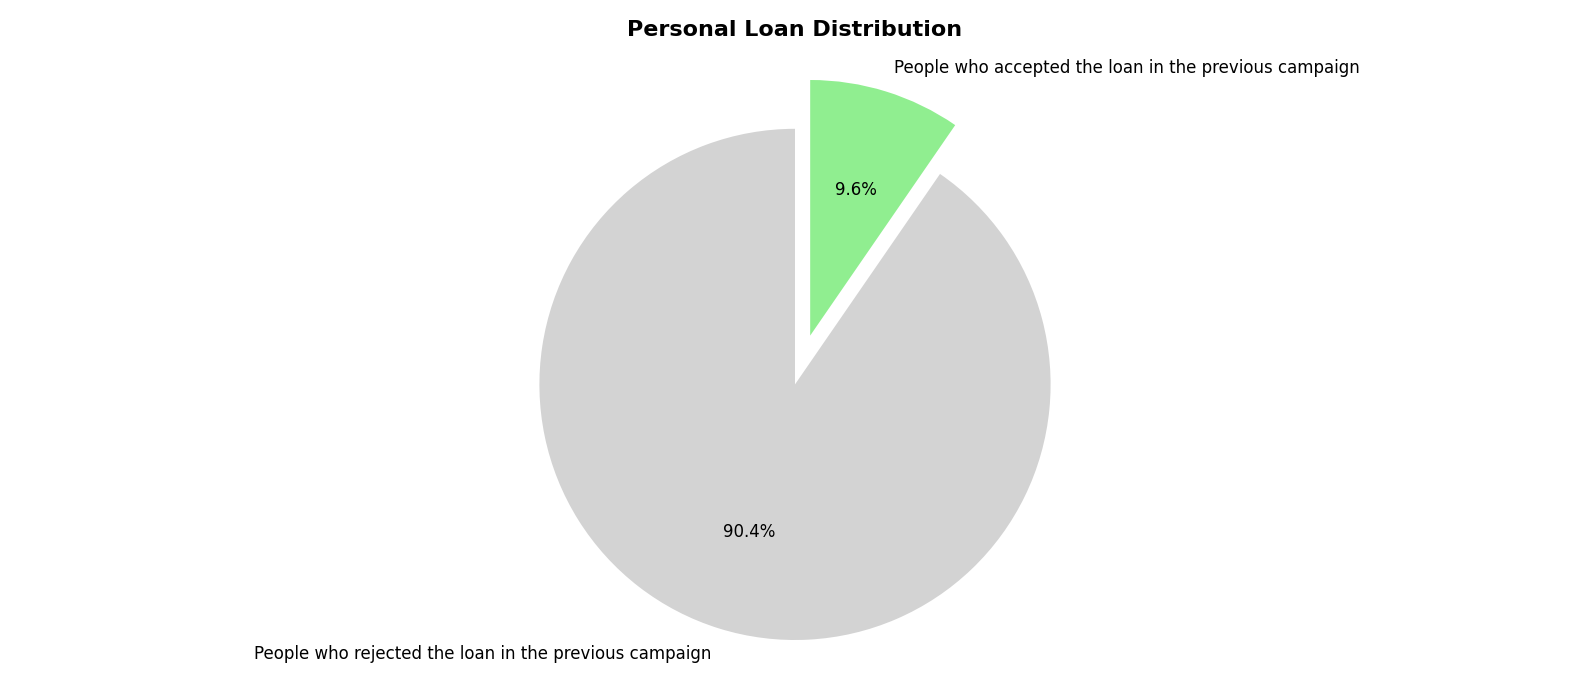

In [35]:
#Personal_Loan

Loan_count =df['Personal_Loan'].value_counts()

plt.figure(figsize=(10,4), dpi=200)

labels = ['People who rejected the loan in the previous campaign', 'People who accepted the loan in the previous campaign']

plt.pie(Loan_count,labels= labels ,explode=[0.1,0.1],
        autopct="%1.1f%%",colors=['lightgray','lightgreen'], startangle=90,
        textprops={'fontsize': 6})

plt.title('Personal Loan Distribution', fontsize=8, weight="bold")
plt.axis('equal')


plt.show()

9.6 % of all 5000 people accepted the offer, while 90.4 % did not.

### Categorical Columns

In [36]:
Categorical = ['Family', 'Education', 'Securities_Account', 'CD_Account', 'Online', 'Credit_Card']

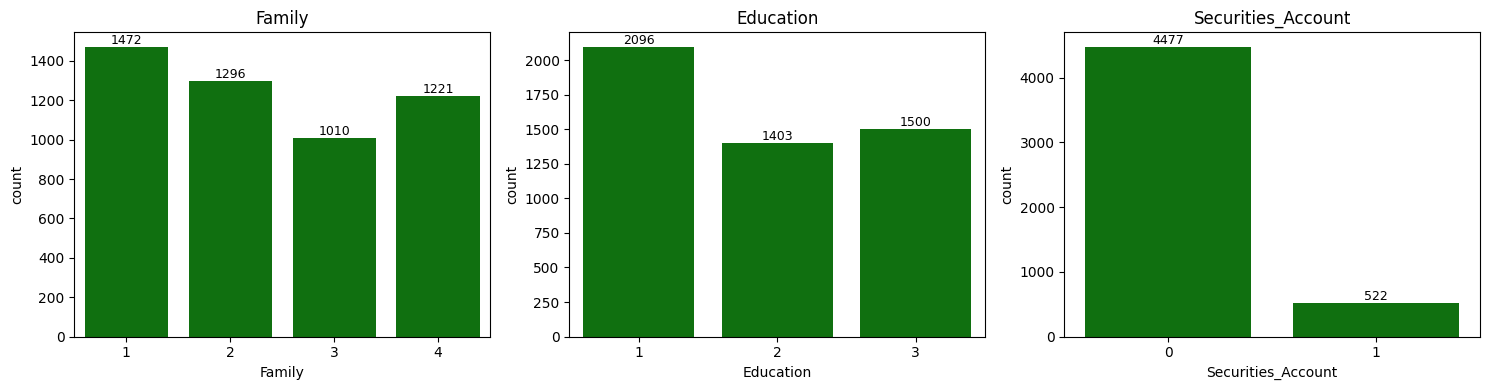

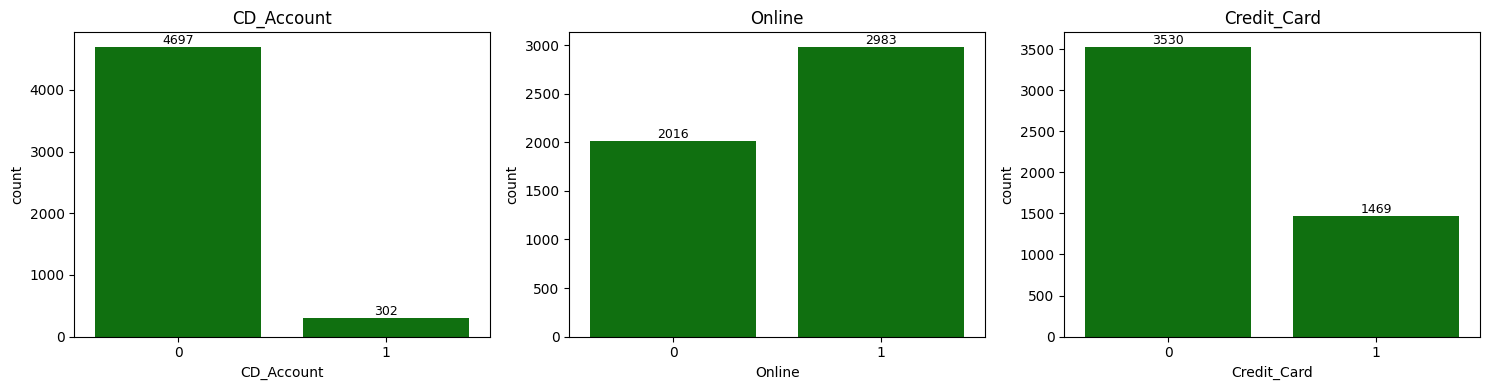

In [37]:
#Visualization_for_categorical_columns

i = 0
while i < len(Categorical):
    fig = plt.figure(figsize=[15,4]) 

    for j in range(1, 4):  
        if i < len(Categorical):
            plt.subplot(1, 3, j)
            ax = sns.countplot(x=Categorical[i], data=df, color='green')
            plt.title(Categorical[i], color='black')

            for p in ax.patches:
                ax.text(
                    p.get_x() + p.get_width() / 2,  
                    p.get_height(),                
                    int(p.get_height()),           
                    ha='center', va='bottom',
                    fontsize=9, color='black'
                )

            i += 1

    plt.tight_layout()
    plt.show()

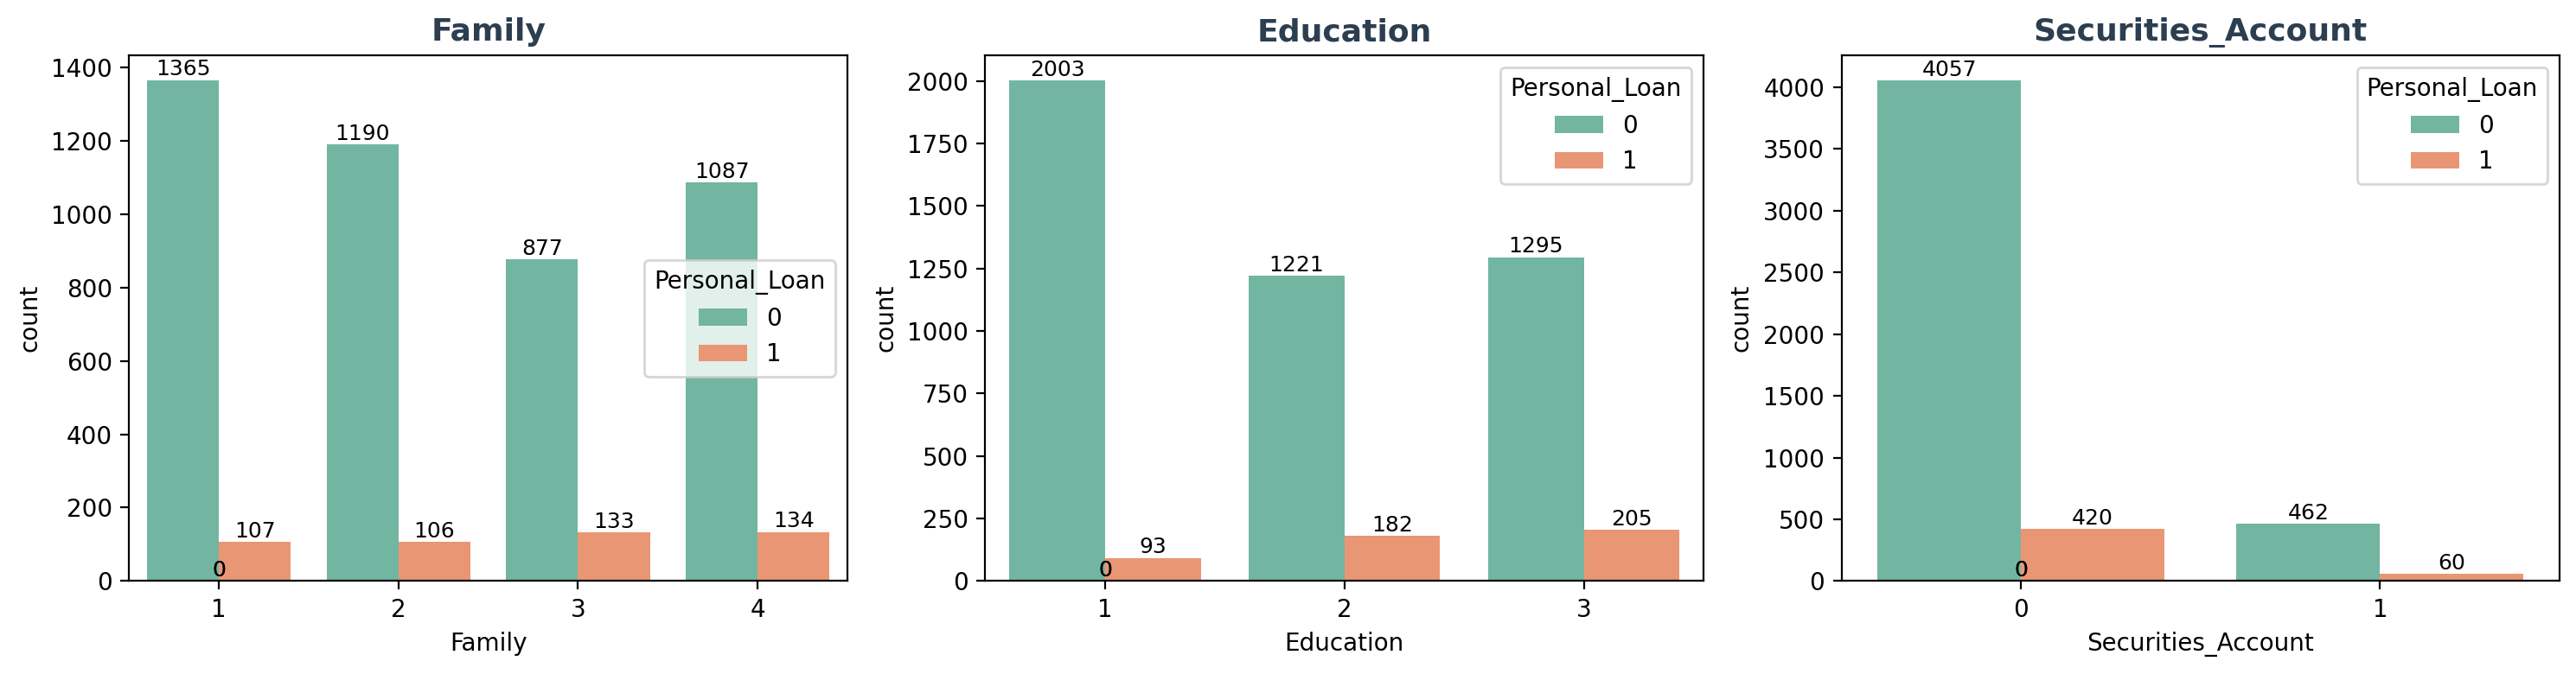

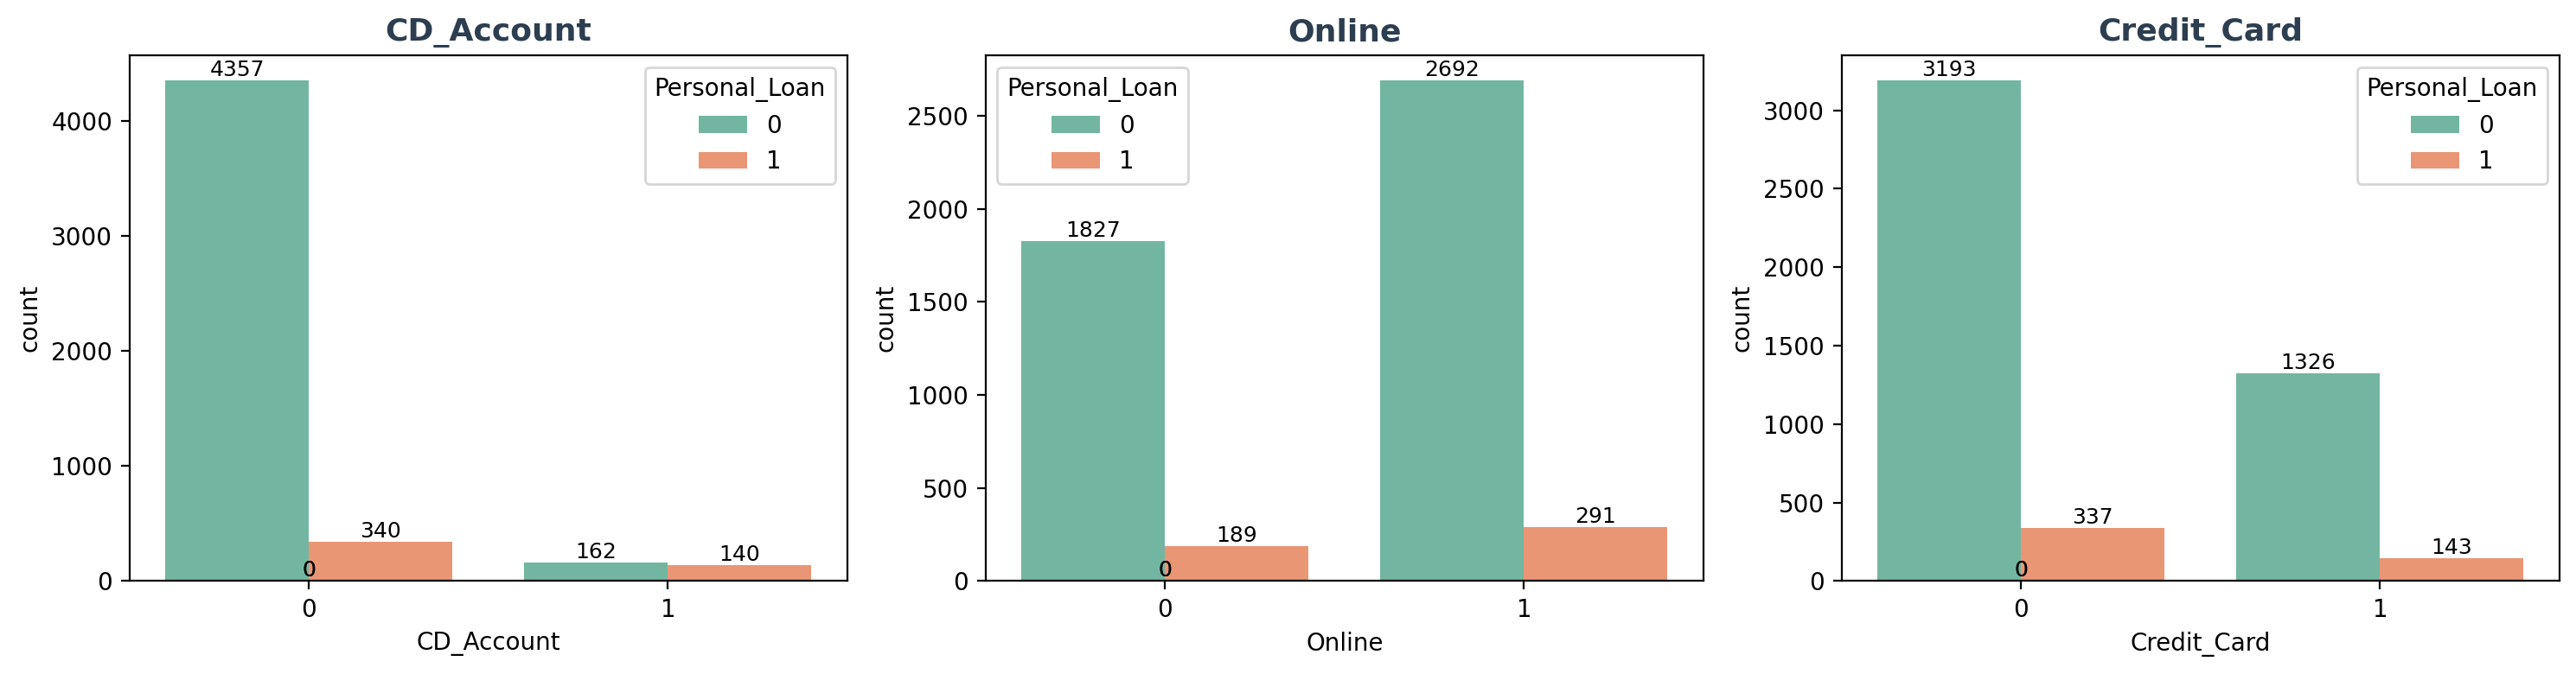

In [38]:
#Visualization_for_categorical_columns
#Colored_by_Personal_Loan_Column
#Count_Plot

i = 0
while i < len(Categorical):
    fig = plt.figure(figsize=[15,4], dpi=200) 

    for j in range(1, 4):
        if i < len(Categorical):
            plt.subplot(1, 3, j)
            ax = sns.countplot(
                x=Categorical[i],
                data=df,
                hue='Personal_Loan',
                palette = 'Set2'
            )
            plt.title(
                Categorical[i],
                color='#2C3E50',
                fontweight='bold',
                fontsize=13)

            for p in ax.patches:
                height = p.get_height()
                ax.text(
                    p.get_x() + p.get_width() / 2,
                    height + 0.5,
                    int(height),
                    ha='center', va='bottom',
                    fontsize=9,
                    color='black')
                
            i += 1

    plt.tight_layout()
    plt.show()

In [39]:
# Acceptance rate per category (easier to compare than raw counts, because the groups differ a lot in size)

for col in Categorical:
    rate = df.groupby(col)['Personal_Loan'].agg(['mean', 'count']).rename(columns={'mean': 'Acceptance_rate', 'count': 'Customers'})
    print(f"--- {col} ---")
    print(rate.round(3), "\n")

--- Family ---
        Acceptance_rate  Customers
Family                            
1                 0.073       1472
2                 0.082       1296
3                 0.132       1010
4                 0.110       1221 

--- Education ---
           Acceptance_rate  Customers
Education                            
1                    0.044       2096
2                    0.130       1403
3                    0.137       1500 

--- Securities_Account ---
                    Acceptance_rate  Customers
Securities_Account                            
0                             0.094       4477
1                             0.115        522 

--- CD_Account ---
            Acceptance_rate  Customers
CD_Account                            
0                     0.072       4697
1                     0.464        302 

--- Online ---
        Acceptance_rate  Customers
Online                            
0                 0.094       2016
1                 0.098       2983 

--- Credit_C

Comparing acceptance **rates** rather than raw counts is important here because the groups have very different sizes. The tables above show that CD account holders, customers with higher education levels, and larger families accept the offer more often.

### Continuous Columns

In [40]:
#Continuous_Columns

Numerical = ['Age', 'Experience', 'Income']

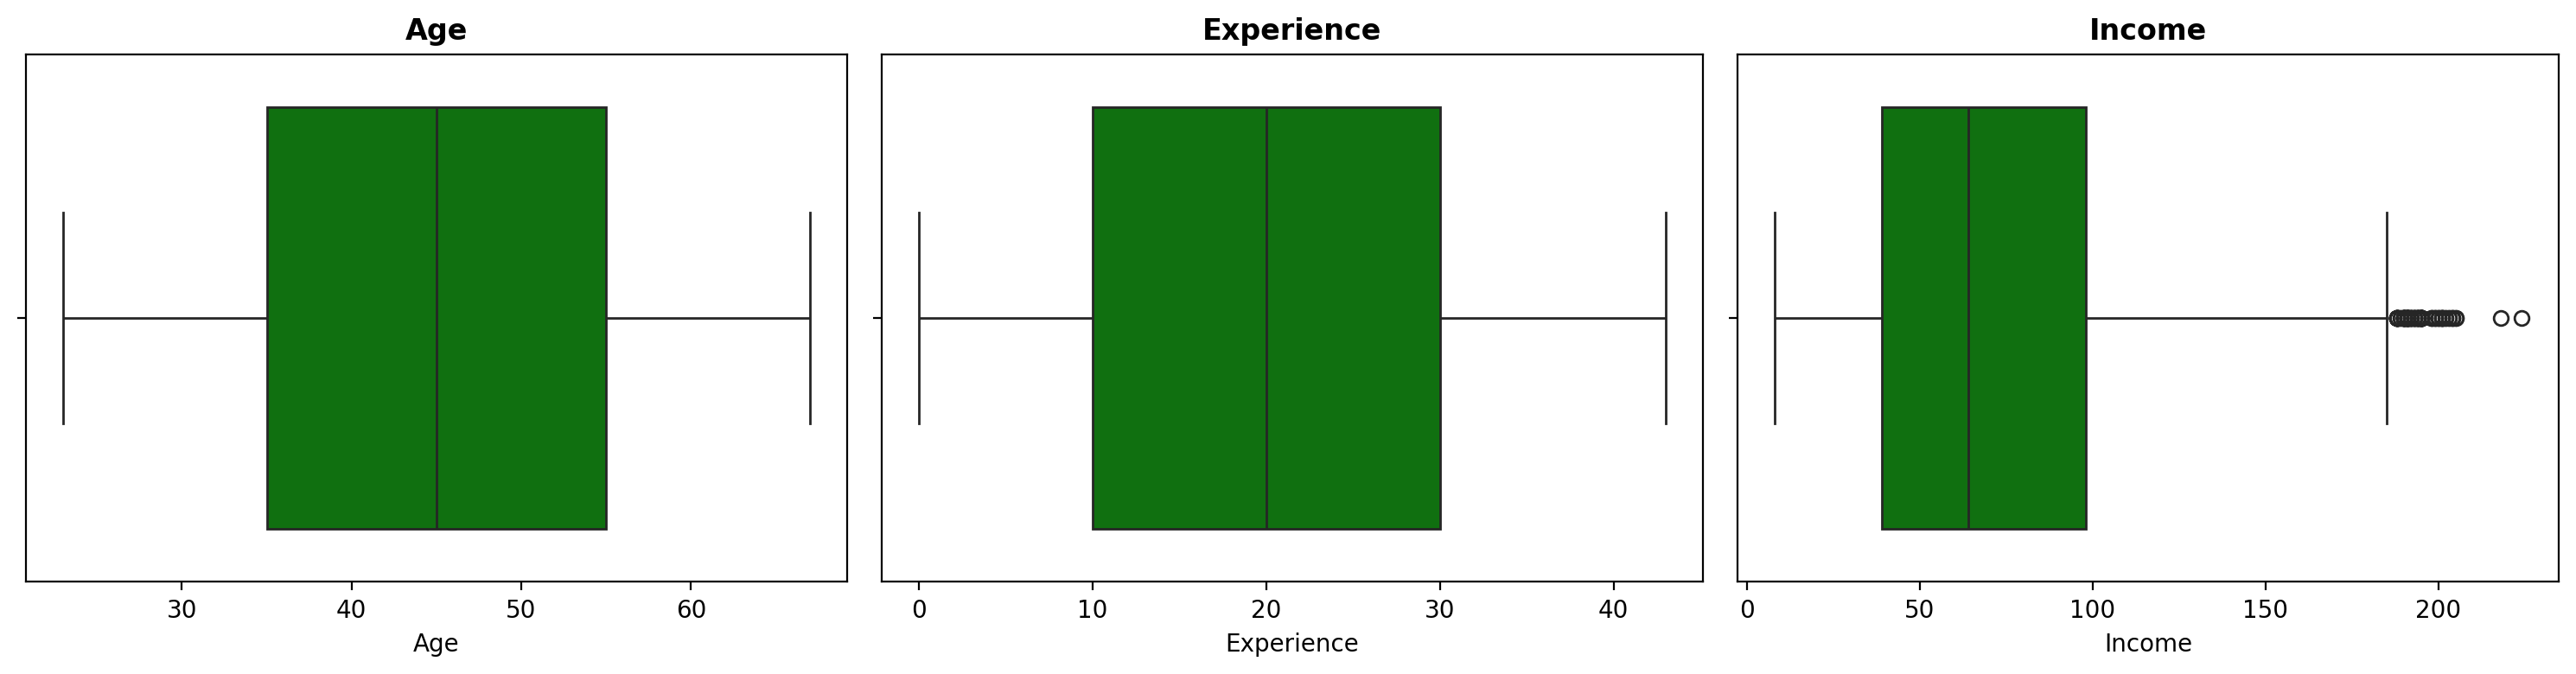

In [41]:
#Visualization_for_continuous_columns
#BoxPlot

fig, axes = plt.subplots(1, 3, figsize=[15,4], dpi=200)
colors = 'green'

for i in range(3):
    sns.boxplot(x= Numerical[i], data=df, ax=axes[i], color=colors)
    axes[i].set_title(Numerical[i], fontweight='bold', color='black')

plt.tight_layout()
plt.show()

I will not remove the outliers in the boxplots: very high incomes are plausible for real customers rather than data errors, and Income is the strongest predictor of loan acceptance (see below), so removing them would discard useful information.

### Income Vs Experience

In [42]:
#Strip_Plot
#Income_Vs_Experience
#Coloured_by_Personal_Loan

fig = px.strip(df, x='Income', y='Experience', color='Personal_Loan', title = 'Income Vs Experience')

fig.add_vline(
    x=60,
    line_width=2,
    line_color="green",
    annotation_text="Income = 60",
    annotation_position="top right"
)

fig.show()

### Age Vs Income

In [43]:
#Strip_Plot
#Age_Vs_Income
#Coloured_by_Personal_Loan

fig = px.strip(df, x='Age', y='Income', color='Personal_Loan', title = 'Age Vs Income')

fig.add_hline(
    y=60,
    line_width=2,
    line_color="green",
    annotation_text="Income = 60",
    annotation_position="top right")

fig.show()

In [44]:
# Lowest income among customers who accepted the loan
print("Lowest income among acceptors:", df.loc[df['Personal_Loan'] == 1, 'Income'].min())

Lowest income among acceptors: 60


A remarkable observation in the two plots above is that no customer with an income below 60 accepted the loan (the lowest income among acceptors is printed above), and acceptance becomes more common as income rises.

### Income Vs Family Size

In [45]:
#Income_Vs_Family_Size
#Colored_by_Personal_Loan

fig = px.strip(df, x='Family', y='Income', color='Personal_Loan', title='Income Vs Family Size')
fig.show()

### Income Vs Education Level

In [46]:
#Income_Vs_Education_Level
#Colored_by_Personal_Loan

fig = px.strip(df, x='Education', y='Income', color='Personal_Loan', title='Income Vs Education Level')
fig.show()

### Family Size Vs Mortgage

In [47]:
#Family_Size_Vs_Mortgage
#Colored_by_Personal_Loan

fig = px.strip(df, x='Family', y='Mortgage', color='Personal_Loan', title='Family Size Vs Mortgage')
fig.show()

### Income Vs Personal Loan

In [48]:
#Income_vs_Personal_Loan

fig = px.strip(df, x='Personal_Loan', y='Income', color='Personal_Loan', hover_data=['Income'])

fig.update_layout(title='Income vs Personal Loan',
                  xaxis_title='Personal_Loan (1=Yes, 0=No)',
                  yaxis_title='Income')
fig.add_hline(y=60, line_color='black', line_width=1 ,annotation_text="Income = 60")

fig.show()

Customers with an income below 60 did not accept the loan offer, while those with an income above 60 either accepted or rejected the loan under different conditions.

### Income vs Personal Loan | Colored by Family Size

In [49]:
#Income_vs_Personal_Loan_colored_by_Family_Size

fig = px.strip(df, x='Personal_Loan', y='Income', color='Family')

fig.update_layout(
    title='Income vs Personal Loan colored by Family Size',
    xaxis_title='Personal Loan (0=No, 1=Yes)',
    yaxis_title='Income'
)

fig.show()

### Income vs Personal Loan | colored by Education

In [50]:
#Income_vs_Personal_Loan_colored_by_Education

fig = px.strip(df, x='Personal_Loan', y='Income', color='Education', title = 'Income vs Personal Loan colored by Education')

fig.add_hline(y=115, line_color='black', line_width=1 ,annotation_text="Income = 115")
fig.add_hline(y=60, line_color='black', line_width=1 ,annotation_text="Income = 60")


fig.show()

The horizontal lines mark income = 60 and income = 115. Instead of judging the thresholds by eye, the cell below prints the lowest income among acceptors for each education level.

In [51]:
# Lowest income among acceptors, per education level
print(df.loc[df['Personal_Loan'] == 1].groupby('Education')['Income'].min())

Education
1    60
2    69
3    64
Name: Income, dtype: int64


## Correlation

In [52]:
# Correlation of every numeric feature with the target
Personal_Loan_corr = df.corrwith(df['Personal_Loan'], numeric_only=True).drop('Personal_Loan')

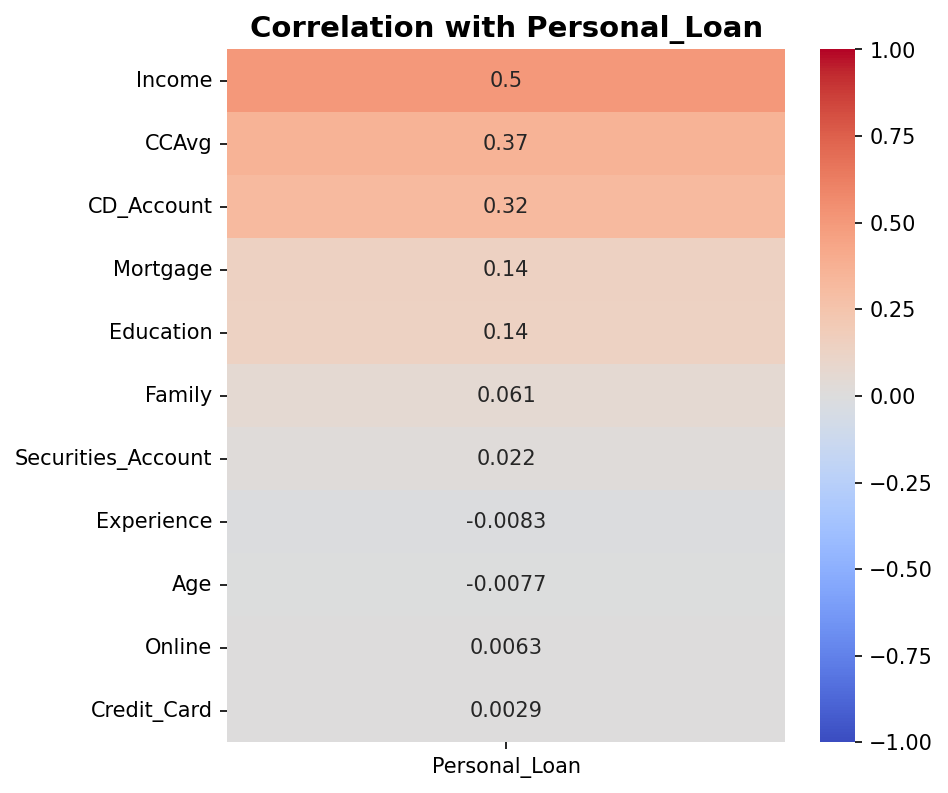

In [53]:
#Correlation_with_target
#Sort_by_absolute_value

corr_sorted = Personal_Loan_corr.abs().sort_values(ascending=False)
corr_df = Personal_Loan_corr.loc[corr_sorted.index].to_frame(name='Personal_Loan')

#HeatMap
plt.figure(figsize=(6,6), dpi=150)
sns.heatmap(corr_df, annot=True, cmap="coolwarm", cbar=True, vmin=-1, vmax=1)

plt.title("Correlation with Personal_Loan", fontsize=14, weight="bold")
plt.show()

### Features Most Correlated with the Target

`Income` > `CCAvg` > `CD_Account` > `Mortgage` > `Education` > `Family`

Correlation only captures linear relationships with the target and is not the same as feature importance. The model coefficients later give a second view.

### Correlation Between Features

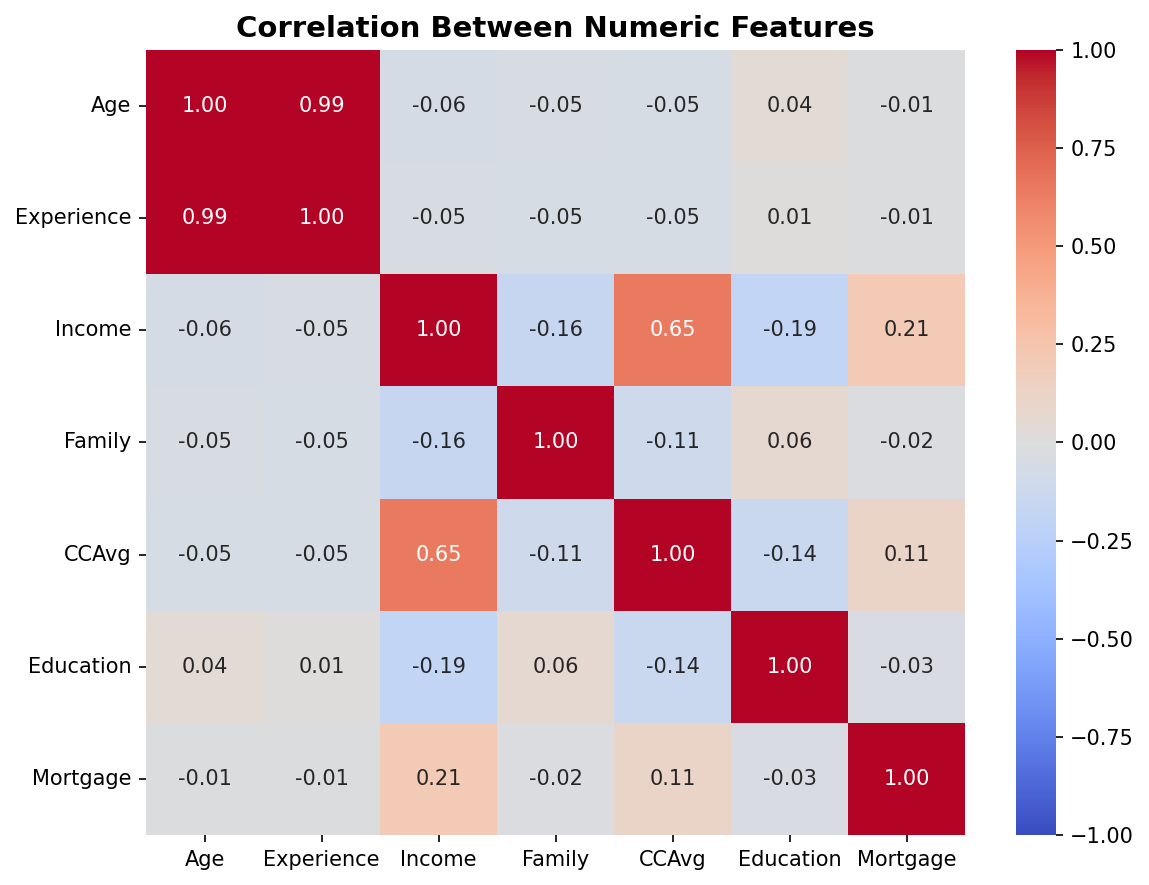

In [54]:
# Correlation between numeric features (to spot redundant features)
num_cols = ['Age', 'Experience', 'Income', 'Family', 'CCAvg', 'Education', 'Mortgage']

plt.figure(figsize=(8, 6), dpi=150)
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Between Numeric Features", fontsize=14, weight="bold")
plt.tight_layout()
plt.show()

Age and Experience are almost perfectly correlated, so they carry nearly the same information. Their individual Logistic Regression coefficients should therefore not be interpreted separately.

## Modeling Setup

- **Target:** `Personal_Loan`; **features:** all the remaining columns.
- **Split:** one stratified 75/25 train/test split (`stratify=y` keeps the ~9.6% acceptance rate in both parts). The split ratio is not a hyperparameter, so I do not compare different ratios on the test set.
- **Preprocessing inside a `Pipeline`:** the scaler and encoder are fitted on training data only, which avoids data leakage. Numeric features are min-max scaled, `Education` and `ZIP3_other` are one-hot encoded (their numeric codes have no meaningful order or spacing), and the 0/1 flags are passed through unchanged.
- **Metrics:** accuracy is misleading on imbalanced data, because predicting "rejected" for everyone already scores about 90%. I use precision, recall, F1, ROC-AUC, PR-AUC and log loss instead. R², MAE and MSE are regression metrics and are not used.

In [55]:
# Features and target
target = 'Personal_Loan'
X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

print("X:", X.shape, "| X_train:", X_train.shape, "| X_test:", X_test.shape)
print("Share of acceptors -> train: {:.3f} | test: {:.3f}".format(y_train.mean(), y_test.mean()))
print("Baseline accuracy (always predict 'rejected'): {:.3f}".format(1 - y_test.mean()))

X: (4999, 12) | X_train: (3749, 12) | X_test: (1250, 12)
Share of acceptors -> train: 0.096 | test: 0.096
Baseline accuracy (always predict 'rejected'): 0.904


In [56]:
numeric_features = ['Age', 'Experience', 'Income', 'Family', 'CCAvg', 'Mortgage']
categorical_features = ['Education', 'ZIP3_other']
binary_features = ['Securities_Account', 'CD_Account', 'Online', 'Credit_Card']


def make_preprocessor(numeric, categorical, binary):
    return ColumnTransformer(
        transformers=[
            ('num', MinMaxScaler(), numeric),
            ('cat', OneHotEncoder(handle_unknown='ignore'), categorical),
            ('bin', 'passthrough', binary)],
        sparse_threshold=0)  # always return a dense array (GaussianNB needs one)


def build(clf, numeric=numeric_features, categorical=categorical_features, binary=binary_features):
    """Preprocessing + classifier in one pipeline."""
    return Pipeline([('prep', make_preprocessor(numeric, categorical, binary)), ('clf', clf)])


# Stratified 5-fold cross-validation, reused for every model
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

### Model 1 | Logistic Regression

Logistic Regression is a natural baseline for a binary target. Because the numeric features are scaled to [0, 1], each coefficient is the change in log-odds when a feature moves from its minimum to its maximum, and `exp(coefficient)` is the corresponding odds ratio.

In [57]:
logreg = build(LogisticRegression(max_iter=1000))
logreg.fit(X_train, y_train)

feature_names = logreg.named_steps['prep'].get_feature_names_out()
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': logreg.named_steps['clf'].coef_[0]})
coef_df['Odds_Ratio'] = np.exp(coef_df['Coefficient'])

print("Intercept:", logreg.named_steps['clf'].intercept_)
coef_df.sort_values('Coefficient', key=lambda s: s.abs(), ascending=False).round(3).reset_index(drop=True)

Intercept: [-7.31514615]


,Feature,Coefficient,Odds_Ratio
0,num__Income,9.123,9164.925
1,bin__CD_Account,3.234,25.371
2,cat__Education_1,-2.013,0.134
3,num__CCAvg,1.885,6.587
4,num__Family,1.403,4.066
5,cat__Education_3,0.998,2.714
6,cat__Education_2,0.965,2.624
7,bin__Credit_Card,-0.927,0.396
8,cat__ZIP3_other_946,-0.790,0.454
9,bin__Securities_Account,-0.674,0.510


### Model 2 | Naive Bayes

I use `GaussianNB`, the variant designed for continuous features. (`MultinomialNB` is meant for count data, so it is not a good fit here.)

In [58]:
nb = build(GaussianNB())
nb.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(sparse_threshold=0,
                                   transformers=[('num', MinMaxScaler(),
                                                  ['Age', 'Experience',
                                                   'Income', 'Family', 'CCAvg',
                                                   'Mortgage']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Education', 'ZIP3_other']),
                                                 ('bin', 'passthrough',
                                                  ['Securities_Account',
                                                   'CD_Account', 'Online',
                                                   'Credit_Card'])])),
                ('clf', GaussianNB())])

### Model 3 | K-Nearest Neighbors (KNN)

The number of neighbors `k` is chosen with `GridSearchCV` using 5-fold stratified cross-validation on the **training set**, scored by F1 (accuracy would favor the majority class). The search starts at k = 3, because with k = 1 the model only memorizes single points. Choosing `k` by looking at test-set accuracy would leak information from the test set.

In [59]:
knn_search = GridSearchCV(
    estimator=build(KNeighborsClassifier()),
    param_grid={'clf__n_neighbors': range(3, 31)},
    scoring='f1', cv=cv, n_jobs=-1)
knn_search.fit(X_train, y_train)

knn = knn_search.best_estimator_
print("Best k:", knn_search.best_params_['clf__n_neighbors'])
print("Best cross-validated F1: {:.3f}".format(knn_search.best_score_))

Best k: 3
Best cross-validated F1: 0.230


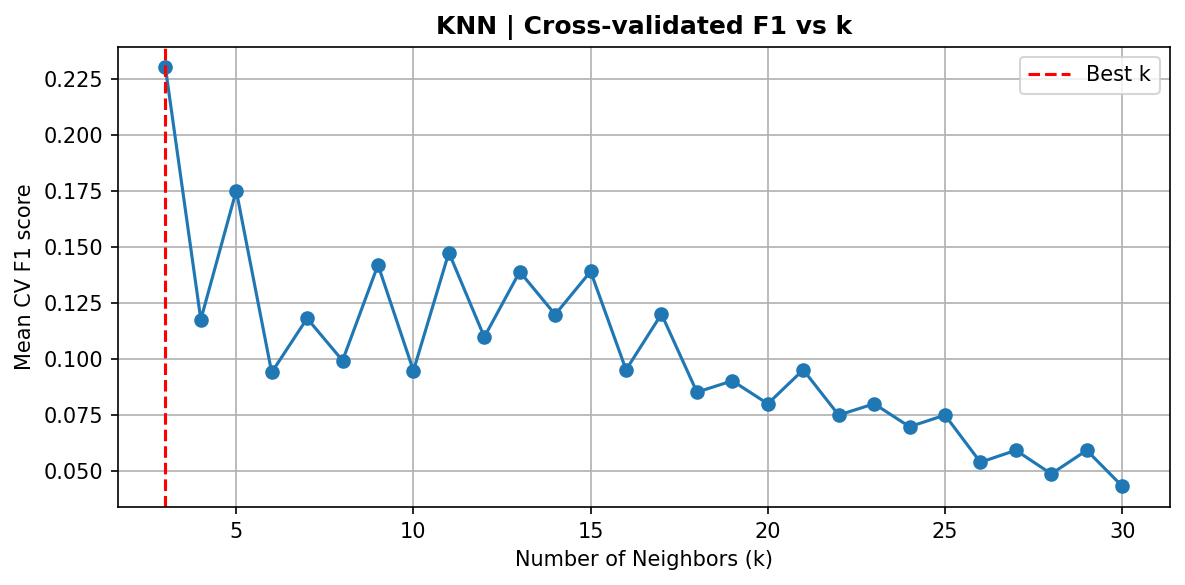

In [60]:
# Cross-validated F1 for each k
cv_results = pd.DataFrame(knn_search.cv_results_)
k_values = cv_results['param_clf__n_neighbors'].astype(int)

plt.figure(figsize=(8, 4), dpi=150)
plt.plot(k_values, cv_results['mean_test_score'], marker='o')
plt.axvline(knn_search.best_params_['clf__n_neighbors'], color='red', linestyle='--', label='Best k')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Mean CV F1 score')
plt.title('KNN | Cross-validated F1 vs k', weight='bold')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

## Improve the Logistic Model

### Class weights

`class_weight='balanced'` makes mistakes on the rare class (acceptors) count more, which usually trades some precision for more recall.

In [61]:
logreg_bal = build(LogisticRegression(max_iter=1000, class_weight='balanced'))

### Interaction features

Interaction terms are products of two features, e.g. `Income × CCAvg`. They let a linear model capture effects that depend on a combination of features. Here they are tested with cross-validation on the training set: I would only keep them if they clearly improve the scores. The main model comparison below uses the base features so that all models see identical inputs.

In [62]:
X_int = X_train.copy()
X_int['Income_x_CCAvg'] = X_int['Income'] * X_int['CCAvg']
X_int['Income_x_CD_Account'] = X_int['Income'] * X_int['CD_Account']

logreg_int = build(LogisticRegression(max_iter=1000),
                   numeric=numeric_features + ['Income_x_CCAvg', 'Income_x_CD_Account'])

metrics_to_check = {'f1': 'f1', 'recall': 'recall', 'roc_auc': 'roc_auc'}
rows = []
for name, model, data in [('Base features', logreg, X_train), ('+ interaction terms', logreg_int, X_int)]:
    s = cross_validate(model, data, y_train, cv=cv, scoring=metrics_to_check, n_jobs=-1)
    rows.append({'Logistic Regression': name, **{m: round(s[f'test_{m}'].mean(), 3) for m in metrics_to_check}})

pd.DataFrame(rows).set_index('Logistic Regression')

,f1,recall,roc_auc
Logistic Regression,,,
Base features,0.701,0.586,0.958
+ interaction terms,0.699,0.583,0.959


## Cross-Validation Comparison

I use 5-fold stratified cross-validation on the training set to see how stable each model is (mean ± standard deviation across folds). Cross-validation estimates how well a model generalizes; it is not used to remove "bad" folds.

Note: KNN's `k` was tuned on these same folds, so its scores here are slightly optimistic. The untouched test set below is the fair comparison.

In [63]:
models = {
    'Logistic Regression': logreg,
    'Logistic Regression (balanced)': logreg_bal,
    'Naive Bayes': nb,
    'KNN': knn,
}

scoring = {'accuracy': 'accuracy', 'precision': 'precision', 'recall': 'recall',
           'f1': 'f1', 'roc_auc': 'roc_auc'}

cv_rows = []
for name, model in models.items():
    scores = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    row = {'Model': name}
    for metric in scoring:
        vals = scores[f'test_{metric}']
        row[metric] = f"{vals.mean():.3f} ± {vals.std():.3f}"
    cv_rows.append(row)

cv_table = pd.DataFrame(cv_rows).set_index('Model')
cv_table

,accuracy,precision,recall,f1,roc_auc
Model,,,,,
Logistic Regression,0.952 ± 0.006,0.880 ± 0.059,0.586 ± 0.057,0.701 ± 0.043,0.958 ± 0.007
Logistic Regression (balanced),0.902 ± 0.008,0.497 ± 0.026,0.894 ± 0.036,0.638 ± 0.019,0.960 ± 0.004
Naive Bayes,0.843 ± 0.016,0.348 ± 0.034,0.717 ± 0.050,0.468 ± 0.040,0.832 ± 0.042
KNN,0.908 ± 0.006,0.597 ± 0.120,0.144 ± 0.042,0.230 ± 0.057,0.701 ± 0.018


### Decision threshold

By default a customer is predicted as an acceptor when the predicted probability is at least 0.5. With imbalanced data a lower threshold often gives a better precision/recall balance. The threshold is chosen from **out-of-fold** predictions on the training set (never from the test set) and is then evaluated once on the test set.

In [64]:
oof_proba = cross_val_predict(logreg, X_train, y_train, cv=cv, method='predict_proba')[:, 1]

rows = []
for t in np.arange(0.10, 0.71, 0.05):
    pred = (oof_proba >= t).astype(int)
    rows.append({'Threshold': round(t, 2),
                 'Precision': precision_score(y_train, pred, zero_division=0),
                 'Recall': recall_score(y_train, pred),
                 'F1': f1_score(y_train, pred)})

threshold_df = pd.DataFrame(rows)
best_threshold = float(threshold_df.loc[threshold_df['F1'].idxmax(), 'Threshold'])
print("Threshold with the best out-of-fold F1:", best_threshold)
threshold_df.round(3)

Threshold with the best out-of-fold F1: 0.3


,Threshold,Precision,Recall,F1
0,0.10,0.448,0.906,0.599
1,0.15,0.544,0.858,0.666
2,0.20,0.622,0.803,0.701
3,0.25,0.695,0.753,0.723
4,0.30,0.753,0.719,0.736
5,0.35,0.785,0.681,0.729
6,0.40,0.839,0.636,0.724
7,0.45,0.866,0.608,0.715
8,0.50,0.876,0.586,0.702
9,0.55,0.900,0.547,0.680


## Evaluation on the Test Set

All models are fitted on the same training set and evaluated once on the same held-out test set.

In [65]:
for model in models.values():
    model.fit(X_train, y_train)


def evaluate(name, model, threshold=0.5):
    proba = model.predict_proba(X_test)[:, 1]
    pred = (proba >= threshold).astype(int)
    return {'Model': name,
            'Accuracy': accuracy_score(y_test, pred),
            'Precision': precision_score(y_test, pred, zero_division=0),
            'Recall': recall_score(y_test, pred),
            'F1': f1_score(y_test, pred),
            'ROC-AUC': roc_auc_score(y_test, proba),
            'PR-AUC': average_precision_score(y_test, proba),
            'Log Loss': log_loss(y_test, proba)}


rows = [evaluate(name, model) for name, model in models.items()]
rows.insert(1, evaluate(f'Logistic Regression (threshold {best_threshold})', logreg, best_threshold))

results = pd.DataFrame(rows).set_index('Model')
results.round(3)

,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Log Loss
Model,,,,,,,
Logistic Regression,0.962,0.950,0.633,0.760,0.962,0.855,0.121
Logistic Regression (threshold 0.3),0.954,0.750,0.775,0.762,0.962,0.855,0.121
Logistic Regression (balanced),0.901,0.491,0.875,0.629,0.965,0.832,0.238
Naive Bayes,0.858,0.363,0.642,0.464,0.839,0.486,0.801
KNN,0.918,0.793,0.192,0.309,0.684,0.299,1.950


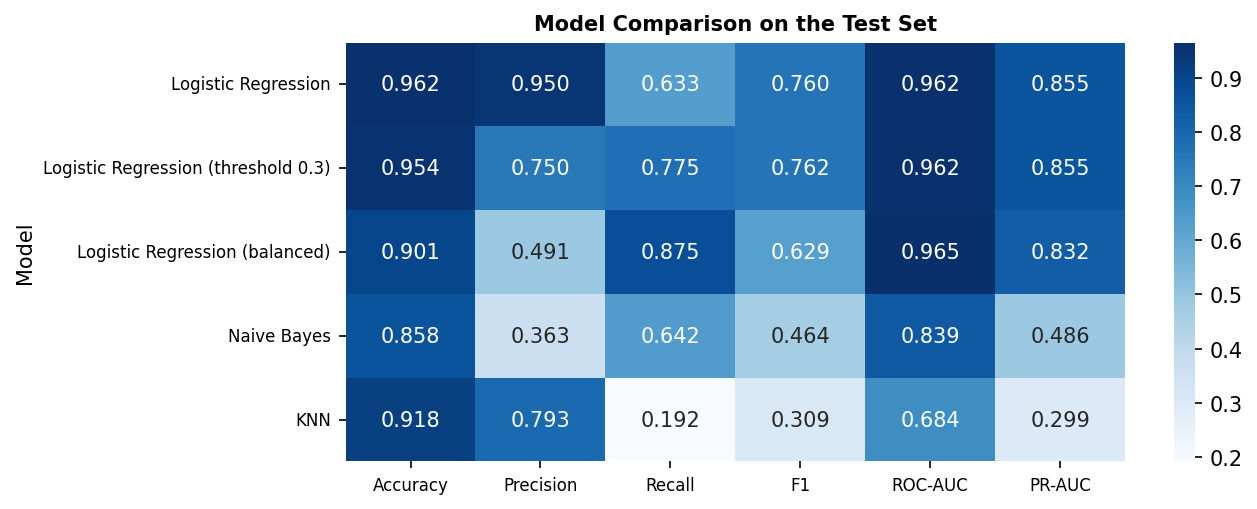


Best Accuracy : Logistic Regression (0.962)
Best Precision: Logistic Regression (0.950)
Best Recall   : Logistic Regression (balanced) (0.875)
Best F1       : Logistic Regression (threshold 0.3) (0.762)
Best ROC-AUC  : Logistic Regression (balanced) (0.965)
Best PR-AUC   : Logistic Regression (0.855)
Lowest Log Loss: Logistic Regression (0.121)


In [66]:
#HeatMap
#Compare_Models (Log Loss is shown separately because lower is better)

plt.figure(figsize=(9, 3.5), dpi=150)
sns.heatmap(results.drop(columns='Log Loss'), annot=True, cmap='Blues', fmt=".3f")
plt.title("Model Comparison on the Test Set", fontsize=10, weight="bold")
plt.yticks(fontsize=8)
plt.xticks(fontsize=8)
plt.tight_layout()
plt.show()

print()
for metric in ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC', 'PR-AUC']:
    print(f"Best {metric:<9}: {results[metric].idxmax()} ({results[metric].max():.3f})")
print(f"Lowest Log Loss: {results['Log Loss'].idxmin()} ({results['Log Loss'].min():.3f})")

### Confusion Matrices (test set)

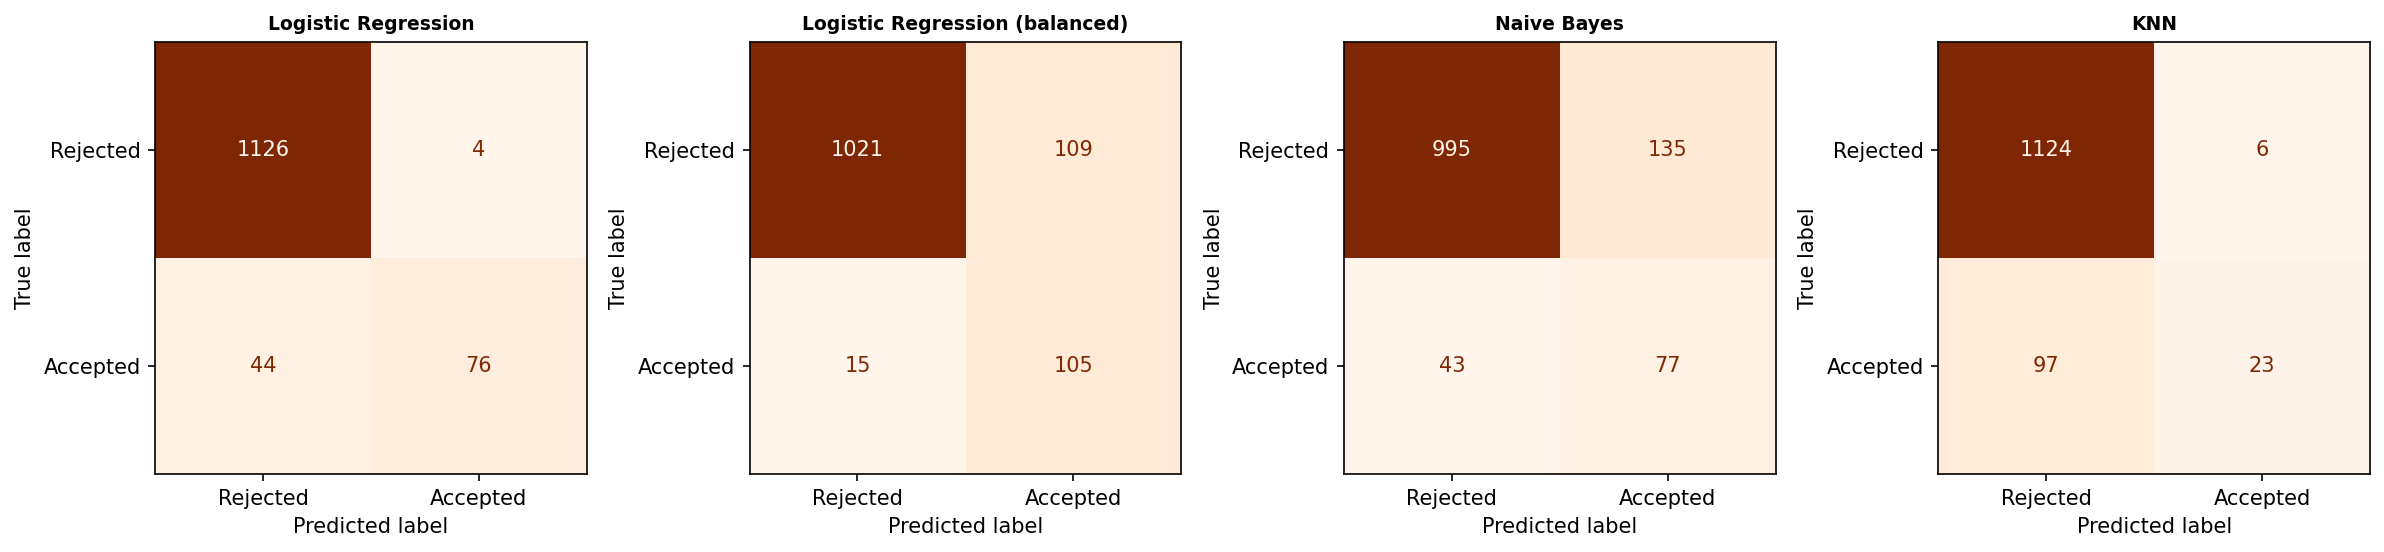

In [67]:
fig, axes = plt.subplots(1, len(models), figsize=(4 * len(models), 3.8), dpi=150)

for ax, (name, model) in zip(axes, models.items()):
    ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, ax=ax,
                                          cmap='Oranges', colorbar=False,
                                          display_labels=['Rejected', 'Accepted'])
    ax.set_title(name, fontsize=9, weight='bold')
    ax.grid(False)

plt.tight_layout()
plt.show()

In [68]:
print(classification_report(y_test, logreg.predict(X_test), target_names=['Rejected', 'Accepted']))

              precision    recall  f1-score   support

    Rejected       0.96      1.00      0.98      1130
    Accepted       0.95      0.63      0.76       120

    accuracy                           0.96      1250
   macro avg       0.96      0.81      0.87      1250
weighted avg       0.96      0.96      0.96      1250



### ROC and Precision-Recall Curves (test set)

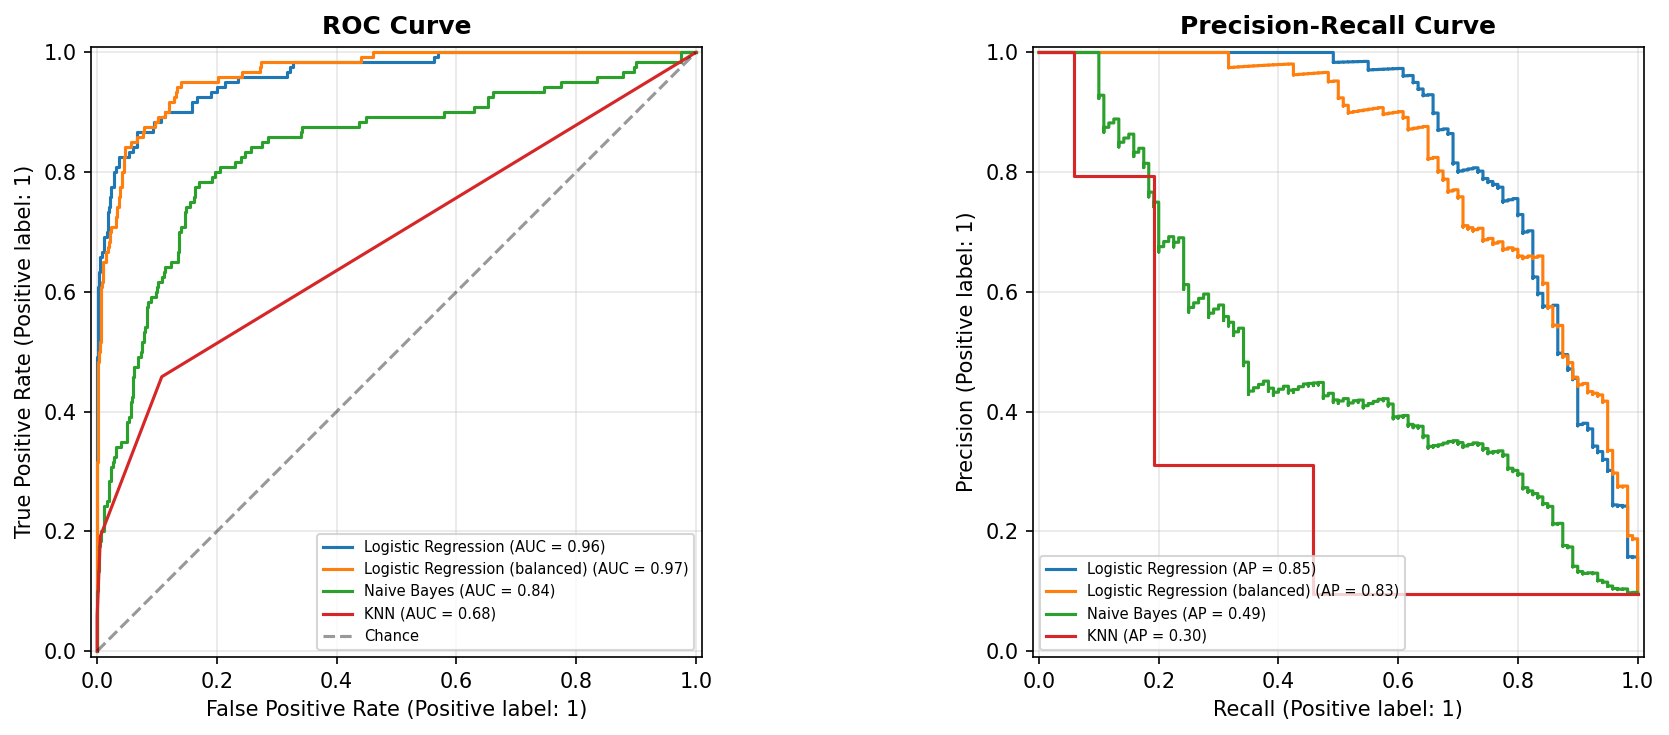

In [69]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=150)

for name, model in models.items():
    RocCurveDisplay.from_estimator(model, X_test, y_test, name=name, ax=axes[0])
    PrecisionRecallDisplay.from_estimator(model, X_test, y_test, name=name, ax=axes[1])

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Chance')
axes[0].set_title('ROC Curve', weight='bold')
axes[1].set_title('Precision-Recall Curve', weight='bold')
for ax in axes:
    ax.grid(alpha=0.3)
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

### How to Read the Results

- **Accuracy is not enough.** A model that predicts "rejected" for every customer already reaches the baseline accuracy printed earlier (about 90%), so accuracy alone says little about how well acceptors are found.
- **Precision vs recall.** Precision is the share of predicted acceptors who really accept; recall is the share of real acceptors the model finds. For a campaign, the right balance depends on the cost of contacting a customer who will refuse versus missing one who would have accepted. Class weights and a lower decision threshold move the model toward higher recall at the cost of precision.
- **Probability quality.** ROC-AUC and PR-AUC measure how well a model *ranks* customers, and log loss measures how good the predicted probabilities are. KNN with a small `k` can only output coarse probabilities (multiples of 1/k), which is why its log loss tends to be poor even when its labels are accurate. Naive Bayes probabilities are typically over-confident.
- **A very high precision can be misleading** when the model predicts very few positives, because it rests on only a handful of predictions. Always read precision together with recall.
- **Choosing a model:** use the table above together with the business goal: for ranking customers to call first, compare ROC-AUC, PR-AUC and log loss; for finding as many acceptors as possible, compare recall and F1 (including the class-weighted and threshold-tuned Logistic Regression variants).

## Prediction of Sample Customers

The pipeline applies the scaling and encoding by itself, so a new customer is given in the **original units** (after the same cleaning as the training data: CCAvg is an annual amount in $000).

- Customer A is the original sample. In the raw file its CCAvg would be written as `1/2` (that is 1.2 per month, so 1.2 × 12 per year), Education 3 = Advanced/Professional, and ZIP code 92037 becomes `920`.
- Customer B has a high income, a CD account and a high education level: the profile the EDA associated with acceptors.

In [70]:
samples = pd.DataFrame([
    {'Age': 42, 'Experience': 16, 'Income': 30, 'Family': 3, 'CCAvg': 1.2 * 12, 'Education': 3,
     'Mortgage': 10, 'Securities_Account': 1, 'CD_Account': 0, 'Online': 1, 'Credit_Card': 1,
     'ZIP3_other': '920'},
    {'Age': 45, 'Experience': 20, 'Income': 130, 'Family': 4, 'CCAvg': 4.5 * 12, 'Education': 3,
     'Mortgage': 0, 'Securities_Account': 0, 'CD_Account': 1, 'Online': 1, 'Credit_Card': 0,
     'ZIP3_other': '941'},
], index=['Customer A (income 30)', 'Customer B (income 130)'])[X_train.columns]

proba_table = pd.DataFrame({name: model.predict_proba(samples)[:, 1] for name, model in models.items()},
                           index=samples.index)
print("Predicted probability of accepting the loan:")
proba_table.round(3)

Predicted probability of accepting the loan:


,Logistic Regression,Logistic Regression (balanced),Naive Bayes,KNN
Customer A (income 30),0.003,0.009,0.017,0.000
Customer B (income 130),0.976,0.998,1.000,0.333


In [71]:
print("Predicted class at the default 0.5 threshold (1 = accepts, 0 = rejects):")
(proba_table >= 0.5).astype(int)

Predicted class at the default 0.5 threshold (1 = accepts, 0 = rejects):


,Logistic Regression,Logistic Regression (balanced),Naive Bayes,KNN
Customer A (income 30),0,0,0,0
Customer B (income 130),1,1,1,0


Customer A has an income below 60, and the EDA showed that nobody below that income accepted the offer, so a low probability is the expected outcome. Customer B is a more informative test, because the models have to weigh several signals at once.

## Conclusion & Next Steps

**What the analysis shows**

- The data is highly imbalanced (about 9.6% acceptors), so models must be judged with precision, recall, F1, ROC-AUC and PR-AUC rather than accuracy.
- Income, CD account, education, credit card spending and family size are the strongest signals in the EDA.
- All preprocessing sits inside a pipeline and all tuning uses cross-validation on the training set, so the test-set scores are an honest estimate.

**Limitations**

- One train/test split; a repeated or nested cross-validation would give a more stable estimate.
- The data comes from a single campaign in one state, so it should not be treated as a general lending model.

**Next steps**

- Try tree-based models (Decision Tree, Random Forest, Gradient Boosting), which handle threshold-like rules such as the income cut-offs seen in the EDA.
- Tune Logistic Regression (regularization strength `C`) and compare models with a cost-sensitive metric based on campaign costs.